In [21]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [23]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [24]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [25]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [26]:
def load_preprocess(image_path, mask_path):
    image = tf.io.read_file(image_path)
    mask = tf.io.read_file(mask_path)

    image = tf.image.decode_png(image, channels=3)
    mask = tf.image.decode_png(mask, channels=1)

    resized_image = tf.image.resize(image, [375, 1242])
    resized_mask = tf.image.resize(mask, [375, 1242], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [29]:
dataset = dataset.map(load_preprocess)

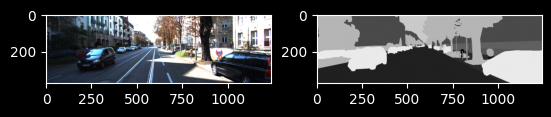

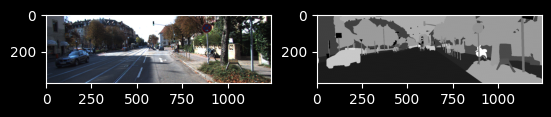

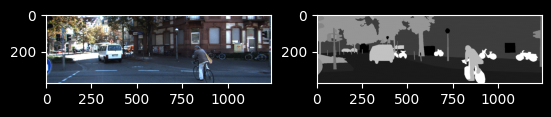

In [40]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [41]:
train_ds = dataset.take(160).shuffle(160).batch(4).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(4).prefetch(tf.data.AUTOTUNE)